**Table of contents**<a id='toc0_'></a>    
- 1. [Setup](#toc1_)    
  - 1.1. [Load Dataset](#toc1_1_)    
  - 1.2. [Load kết quả:](#toc1_2_)    
- 2. [Prompting Configuration](#toc2_)    
- 3. [Đánh giá](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Setup](#toc0_)

In [2]:
# import torch

# print(torch.__version__)
# print(torch.version.cuda)

# if torch.cuda.is_available():
#     print(torch.cuda.get_device_name(0))

# # !nvidia-smi

In [3]:
# # Kiểm tra root_dir trên Kaggle
# import os
# print(os.listdir("/kaggle/input/datasets/nostagiguideus17"))


# # Thiết lập để import source code
# import sys
# sys.path.append("/kaggle/input/datasets/nostagiguideus17/abstractive-summary-vers-transformer")


# # Cài đặt thêm lib cần thiết
# !pip install -q evaluate
# !pip install -q bert_score

# input_path = "/kaggle/input/datasets/nostagiguideus17/abstractive-summary-vers-transformer"

input_path = "."

## 1.1. <a id='toc1_1_'></a>[Load Dataset](#toc0_)

In [4]:
import pandas as pd
from datasets import Dataset

train_set_path = input_path + "/data/train-00000-of-00001.parquet"

dataset = Dataset.from_parquet(train_set_path)
df = dataset.to_pandas()
# df.to_csv('train.csv', index=False, encoding="utf-8-sig")

df.head()
df = df[:5]

## 1.2. <a id='toc1_2_'></a>[Load kết quả:](#toc0_)

Ở đây ta có thể sử dụng mô hình dự đoán trực tiếp, hoặc load kết quả từ file.

Đầu vào gồm:
- predictions: [List, pd.Series] văn bản dự đoán (bản do mô hình viết)
- references:  [List, pd.Series] văn bản đối chiếu (bản tóm tắt chuẩn của dataset)
- original:    [List, pd.Series] văn bản gốc chưa tóm tắt -> Để nếu cần khi đánh giá bằng LLM (đang code)

In [5]:
# originals = [
#     "", "", ""
# ]
# predictions = [
#     "Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5, bao gồm Lễ hội Du lịch Hà Nội 2024, các triển lãm và lễ hội văn hóa, nhằm thu hút cả du khách và người dân.  Song song đó, thành phố cũng đẩy mạnh các sản phẩm du lịch xanh và chuẩn bị chu đáo để đáp ứng nhu cầu tăng cao trong kỳ nghỉ lễ 5 ngày, kỳ vọng thu hút nhiều khách du lịch trong và ngoài nước. ",
#     "Việt Nam đã xuất sắc giành chiến thắng trong trận đấu tối qua.",
#     "Thời tiết hôm nay rất đẹp."
# ]
# references = [
#     "Hà Nội đã tổ chức lễ hội trên toàn thành phố, kéo dài từ 19/4 đến 10/5. Một số hoạt động tiêu biểu bao gồm Lễ hội Du lịch Hà Nội 2024 với chủ đề 'Thăng Long - Hà Nội, Thủ đô quyến rũ'; Triển lãm Ngô Quyền - Anh hùng dân tộc kiệt xuất và Thăng Long hội tụ các chiến thắng làm thay đổi dòng chảy lịch sử thế giới hay Tái hiện lễ hội Cầu mưa dân tộc Lô Lô, tỉnh Cao Bằng. Các sản phẩm du khách sẽ phục vụ chuyên nghiệp, chu đáo để đáp ứng nhu cầu của du khách trong kỳ nghỉ lễ nêu trên, ngành du lịch sẽ phục vụ chuyên nghiệp, chu đáo, đáp ứng tốt nhất nhu cầu tham quan, giải trí và thu hút nhiều khách quốc tế ghé thăm.",
#     "Đội tuyển Việt Nam giành chiến thắng thuyết phục vào tối hôm qua.",
#     "Hôm nay trời nắng và thời tiết rất đẹp."
# ]

In [6]:
import pandas as pd

predict_dir = input_path + "/results.csv"

df = pd.read_csv(predict_dir)

originals = df['article']
references = df['reference']
predictions = df['prediction']

# 2. <a id='toc2_'></a>[Prompting Configuration](#toc0_)

In [14]:
# Prompt là một pattern sở hữu đủ 3 tham số: original, reference, prediction
# Response_key phải khớp với format (JSON) được trả về.

PROMPT = """
            Choose a more relevant summary from Summary #1 and
            Summary #2 with respect to the corresponding Article by choosing an option from A, B, or C. 
            Note that relevance measures the summary’s selection of important content from the Article,
            whether the summary grasps the main message of the Article without being overwhelmed by unnecessary or less significant details.
            
            Original article: {original}
            Reference: {reference}
            Prediction: {prediction}

            A (Score 0): Prediction summary is totally unrelevant to the original Article.
            B (Score 0.5): Reference is more relevant.
            C (Score 0.7): Both Reference and Prediction summary are equally relevant.
            D (Score 1): Prediction summary is more relevant.

            Your Answer must return as json which contains score respective to the choice A to D you have made, and attachs a minor comment in Vietnamese if you could. 
            For example:
            {{
                "score": 0.5,
                "comment": "Bản tóm tắt gốc (Reference) chi tiết hơn bản tóm tắt được dự đoán (Prediction)."
            }}

        """

RESPONSE_KEY = ['score', 'comment']

In [15]:
# Config: Chỉ cần bắt đầu với `llm` thì sẽ chuyển prompt cho llm đánh giá.

evaluation_config = {
    "rouge": {
        "rouge_types": ["rouge1", "rouge2", "rouge3", "rougeL", "rougeLsum"],
        "use_stemmer": True
    },
    "bertscore": {
        "model_type": "xlm-roberta-large",
        "verbose": True, # BẬT thanh tiến trình cho BERTScore
        "lang": "vi",
        "use_fast_tokenizer": True
    },
    "llm_test": {
        # --- Nếu dùng OLLAMA ( localhost ) ---
        "provider": "ollama", 
        "model_name": "qwen2.5:3b",
        
        # --- Nếu dùng GROQ ---
        # "provider": "groq",
        # "model_name": "llama-3.1-8b-instant",
        # "api_key": "gsk_xxxxxxx",
        
        # --- Nếu dùng LOCAL ---
        # "provider": "local",
        # "model_name": "Qwen/Qwen2.5-0.5B",


        # --- Prompt Engineering ---
        "prompt" : PROMPT,
        "response_key" : RESPONSE_KEY
    }
}

# 3. <a id='toc3_'></a>[Đánh giá](#toc0_)

In [16]:
from src.evaluate import MultiEvaluator

evaluator = MultiEvaluator(evaluation_config)

[Info] Đang tải các mô hình đánh giá. Việc này có thể mất chút thời gian...
[Info] Đã tải xong metric: rouge
[Info] Đã tải xong metric: bertscore
[Info] Khởi tạo LLMEvaluator với provider: OLLAMA, model: qwen2.5:3b
[Info] Đã tải xong metric: llm_test


In [17]:
results = evaluator.score_batch(
    references,
    predictions, 
    originals
)

# results.to_csv("kaggle/working/results.csv")
results.to_csv("evaluation_results.csv")
results

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 5037.00 seconds, 0.00 sentences/sec


LLM judge progress: 100%|██████████| 10/10 [00:31<00:00,  3.14s/it]


,rouge1,rouge2,rouge3,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,llm_test_score,llm_test_comment
0,0.737968,0.473118,0.345946,0.475936,0.475936,0.906796,0.920769,0.913729,0.7,Bản tóm tắt Prediction và Reference đều mô tả ...
1,0.627063,0.385382,0.274247,0.389439,0.389439,0.918960,0.903534,0.911182,0.7,Cả Bản tóm tắt gốc (Reference) và Bản tóm tắt ...
2,0.781095,0.605000,0.497487,0.497512,0.497512,0.912585,0.912454,0.912519,0.7,Tảm tọng tắt Prediction rất phù hợp với nội du...
3,0.666667,0.452722,0.317003,0.415954,0.415954,0.907508,0.879185,0.893122,0.7,Bản tóm tắt Prediction có độ tương quan cao vớ...
4,0.828479,0.671010,0.590164,0.724919,0.724919,0.949079,0.947652,0.948365,0.7,Bản tóm tắt Prediction và Reference đều tập tr...
5,0.671937,0.310757,0.200803,0.403162,0.403162,0.898386,0.902222,0.900300,0.7,Bản tóm tắt được dự đoán (Prediction) giữ nguy...
6,0.719101,0.457627,0.289773,0.449438,0.449438,0.881243,0.897614,0.889353,0.7,Bản tóm tắt Prediction và Reference đều mô tả ...
7,0.600000,0.187050,0.057971,0.278571,0.278571,0.870324,0.858441,0.864341,0.7,Bảng tóm tắt được dự đoán tương đồng với thông...
8,0.627273,0.266055,0.129630,0.336364,0.336364,0.893492,0.874245,0.883763,0.7,Bản tóm tắt Prediction và Reference đều phản á...
9,0.598291,0.406877,0.242075,0.415954,0.415954,0.918267,0.885113,0.901385,0.7,Bảng tóm tắt gốc và dự đoán đều nhấn mạnh trọn...


In [18]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_rouge(df: pd.DataFrame, columns: list, fig_name:str = "Evaluation Scores") -> plt.Figure:
    """
    Vẽ biểu đồ cột thể hiện giá trị Min, Mean, Max của các độ đo ROUGE.
    
    Args:
        df: DataFrame chứa kết quả đánh giá.
        columns: Danh sách tên các cột cần vẽ (VD: ['rouge1', 'rouge2', 'rouge3', 'rougeLsum']).
        
    Returns:
        fig: Đối tượng Figure của matplotlib.
    """
    # 1. Trích xuất dữ liệu thống kê
    min_vals = df[columns].min()
    mean_vals = df[columns].mean()
    max_vals = df[columns].max()
    
    # 2. Thiết lập thông số tọa độ cho các cột
    x = np.arange(len(columns))  # Vị trí tâm của từng cụm (tick marks)
    width = 0.25                 # Độ rộng của mỗi cột
    
    # 3. Khởi tạo Figure và Axes
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 4. Vẽ 3 nhóm cột (Min, Mean, Max)
    # Dịch trục x sang trái cho cột Min, giữ nguyên cho Mean, và dịch sang phải cho Max
    rects_min = ax.bar(x - width, min_vals, width, label='Min', color='#E63946')
    rects_mean = ax.bar(x, mean_vals, width, label='Mean', color='#2A9D8F')
    rects_max = ax.bar(x + width, max_vals, width, label='Max', color='#0077B6')
    
    # 5. Hàm phụ để ghi giá trị lên đỉnh cột
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            # Ghi text tại vị trí tâm của cột, nhích lên trên một chút (xytext=(0, 3))
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
            
    # Áp dụng ghi chú cho cả 3 nhóm cột
    autolabel(rects_min)
    autolabel(rects_mean)
    autolabel(rects_max)
    
    # 6. Trang trí biểu đồ
    ax.set_ylabel('Scores')
    ax.set_title(fig_name)
    ax.set_xticks(x)
    ax.set_xticklabels(columns)
    ax.legend(loc='upper right')
    
    # Mở rộng giới hạn trục Y thêm một chút để không bị lẹm phần text trên đỉnh cột Max
    ax.set_ylim(0, 1.1)
    
    # Thêm lưới mờ theo trục ngang cho dễ nhìn
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    return fig

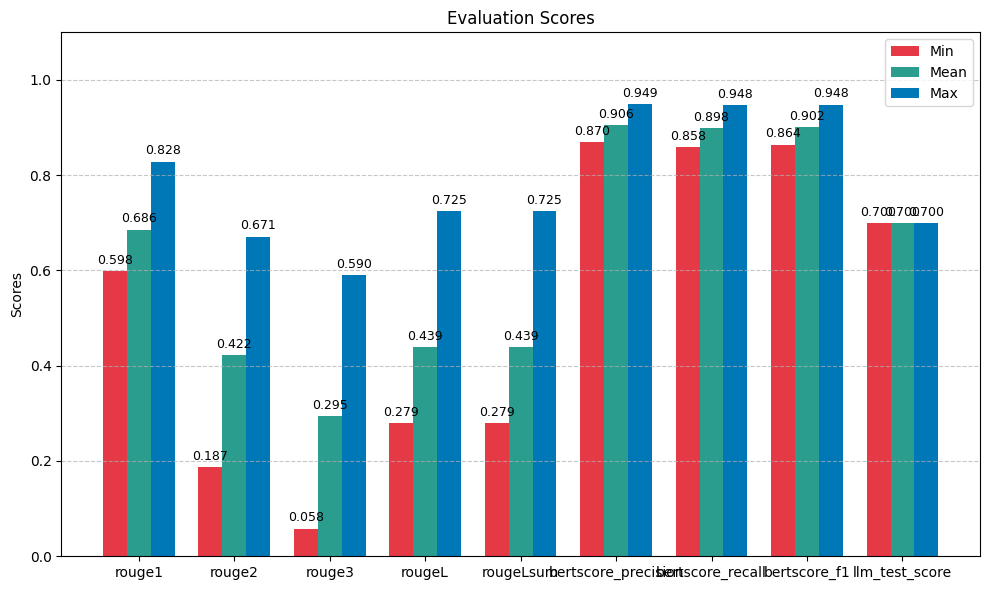

In [19]:
fig = visualize_rouge(results, columns = ['rouge1', 'rouge2', 'rouge3',	'rougeL', 'rougeLsum', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1', 'llm_test_score'])